In [10]:
from FormUtils import pyForm, capture_physics_expr

In [11]:
%%pyForm Compton

* Process: e- gamma -> e- gamma (Compton)
#-
* Above suppresses extra output
Off Statistics;
Off FinalStats;
#include SquareAmplitude.h

* constants
Symbols me, e, pi, alpha, x;

Local Ms = (e^2) * UB(i1, p3, me) * g(i1, i2, mu2) * eps(mu1, p2) 
                 * fprop(i2, i3, q1, me) 
                 * g(i3, i4, mu1) * U(i4, p1, me) * eps(mu2, p4);

Local Mu = (e^2) * UB(i1, p3, me) * g(i1, i2, mu1) * eps(mu1, p2)
                 * fprop(i2, i3, q2 , me) 
                 * g(i3, i4, mu2) * U(i4, p1, me) * eps(mu2, p4);
                

Local Mtot = Ms + Mu;

* Square the total amplitude
#call squareamplitude(Mtot, Msq)
.sort

* Spin averaging (1/2 * 1/2)
multiply 1/4; 
* coupling
id e^4 = 16 * pi^2 * alpha^2;
* propagator handling

repeat;
    id q1 = p1 + p2;
    id q2 = p1 - p4;
endrepeat;
id prop(x?) = (x)^-1;
id (-me^2 + q1.q1)^-1 = (s - me^2)^-1;
id (-me^2 + q2.q2)^-1 = (u - me^2)^-1;
.sort

* Kinematics 
#call Mandelstam2To2(p1,p2,p3,p4,me,0,me,0)

* Final clean up
id u = 2*me^2 - s - t;

Bracket s, alpha, pi ;
* Save
Format C;
#write <Compton.txt> "%e;", Msq;
.sort

* Print
Format;
Print+s  Msq;
.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Wed Apr 15 19:21:28 2026
    
    * Process: e- gamma -> e- gamma (Compton)
    #-

   Msq =
       + 224/( - me^2 + u)/( - me^2 + u)*me^4*pi^2*alpha^2
       - 96/( - me^2 + u)/( - me^2 + u)*t*me^2*pi^2*alpha^2
       - 128/( - me^2 + u)/( - me^2 + u)*s*me^2*pi^2*alpha^2
       + 32/( - me^2 + u)/( - me^2 + u)*s*t*pi^2*alpha^2
       + 32/( - me^2 + u)/( - me^2 + u)*s^2*pi^2*alpha^2
       + 256/( - me^2 + s)/( - me^2 + u)*me^4*pi^2*alpha^2
       - 64/( - me^2 + s)/( - me^2 + u)*t*me^2*pi^2*alpha^2
       + 96/( - me^2 + s)/( - me^2 + s)*me^4*pi^2*alpha^2
       - 32/( - me^2 + s)/( - me^2 + s)*t*me^2*pi^2*alpha^2
       + 32/( - me^2 + s)/( - me^2 + s)*s*t*pi^2*alpha^2
       + 32/( - me^2 + s)/( - me^2 + s)*s^2*pi^2*alpha^2
      ;




<|M^2|> =  32*pi**2*alpha**2*((me**2 - s)**2*(-3*me**4 + 3*me**2*s + 2*me**2*t + 5*me**2*u - s*u) + 2*(me**2 - s)*(me**2 - u)*(6*me**4 - me**2*s - 4*me**2*t - me**2*u + s*t + t**2 + t*u) + (me**2 - u)**2*(-3*me**4 + 5*me**2*s + 2*me**2*t + 3*me**2*u - s*u))/((me**2 - s)**2*(me**2 - u)**2)
dsigma/dOmega =  alpha**2*(-E1**3*(-3*E1*cos(theta)**2 - E1 + cos(theta)**3*Abs(E1) + 3*cos(theta)*Abs(E1)) - 2*E1*(-E1*(cos(theta) - 1) + me)**3 - 2*(-E1*(cos(theta) - 1) + me)**2*(-2*E1**2 - E1*me + 2*E1*cos(theta)*Abs(E1) + me*cos(theta)*Abs(E1)) - (-E1*(cos(theta) - 1) + me)*(3*E1**3*cos(theta)**2 + 3*E1**3 + 2*E1**2*me*cos(theta)**2 + 2*E1**2*me - 6*E1**2*cos(theta)*Abs(E1) + E1*me**2*cos(theta)**2 + E1*me**2 - 4*E1*me*cos(theta)*Abs(E1) - 2*me**2*cos(theta)*Abs(E1)))/(2*E1*(E1*(cos(theta) - 1) - me)**3*(E1*(E1*cos(theta)**2 + E1 - 2*cos(theta)*Abs(E1)) + 2*(-E1 + cos(theta)*Abs(E1))*(-E1*(cos(theta) - 1) + me) + (-E1*(cos(theta) - 1) + me)**2))
Low Energy Limit =  alpha**2*(cos(theta)**2 + 1)/(2

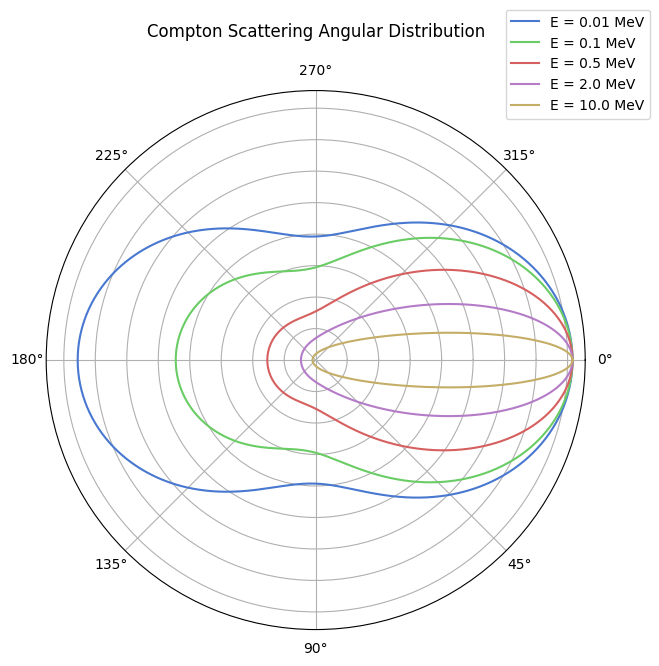

In [12]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from Kinematics import XS_FixedTarget_Lab

plt.style.use("seaborn-v0_8-muted")
plt.rcParams["axes.grid"] = True


# Capture Raw FORM ouput
form_expr = capture_physics_expr("scripts/Compton.txt")
# Convert FORM to sympy
s, t, u, alpha, me = sp.symbols("s t u alpha me")
Msq = sp.simplify(form_expr)
print(f"<|M^2|> =  {Msq}")

# Call the method to get the xs in CM
theta = sp.Symbol("theta", real=True)
E1 = sp.Symbol("E1", real=True)
xs = XS_FixedTarget_Lab(Msq, s, t, u, theta, E1, me)
print(f"dsigma/dOmega =  {xs}")

# 1.Thomson Limit (Low Energy)
xs_thomson = sp.limit(xs, E1, 0)
xs_thomson_simplified = sp.simplify(xs_thomson)
print(f"Low Energy Limit =  {xs_thomson_simplified}")

# lambdify
xs_lambda = sp.lambdify((E1, alpha, me, theta), xs, "numpy")

# Constants
me_val = 0.51099895
alpha_val = 1 / 137.035999
energies = [0.01, 0.1, 0.5, 2.0, 10.0]  # MeV

# Setup the Plots
fig1 = plt.figure(figsize=(7, 7))
ax1 = fig1.add_subplot(111, polar=True)
ax1.set_theta_zero_location("E")  # 0 deg at right
ax1.set_theta_direction(-1)  # Clockwise
ax1.set_yticklabels([])
ax1.set_title("Compton Scattering Angular Distribution", pad=20)

theta_vals = np.linspace(0, 2 * np.pi, 1000)

for E1lab in energies:
    cross_section = []
    cross_section = xs_lambda(E1lab, alpha_val, me_val, theta_vals)
    # Plotting
    ax1.plot(theta_vals, cross_section, label=f"E = {E1lab} MeV")

ax1.legend(loc="upper right", bbox_to_anchor=(1.12, 1.15), borderaxespad=0.0)
plt.show()